In [1]:
!pip install librosa tensorflow scikit-learn matplotlib seaborn

In [2]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
RAVDESS_PATH = "C:/Users/pasha/pca/datasets/speech/ravdess"
SAVEE_PATH = "C:/Users/pasha/pca/datasets/speech/savee"

In [4]:
ravdess_map = {
    "01":"neutral",
    "03":"happy",
    "04":"sad",
    "05":"angry",
    "06":"fear",
    "07":"disgust"
}

In [5]:
savee_map = {
    "a":"angry",
    "d":"disgust",
    "f":"fear",
    "h":"happy",
    "n":"neutral",
    "sa":"sad"
}

In [6]:
def extract_features(audio, sr=22050, n_mels=128, max_len=130):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels
    )

    log_mel = librosa.power_to_db(mel)

    if log_mel.shape[1] < max_len:

        pad = max_len - log_mel.shape[1]

        log_mel = np.pad(
            log_mel,
            ((0,0),(0,pad)),
            mode="constant"
        )

    else:
        log_mel = log_mel[:, :max_len]

    return log_mel

In [7]:
def augment_audio(audio, sr=22050):

    augmented = []

    noise = audio + 0.005*np.random.randn(len(audio))
    augmented.append(noise)

    pitch = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
    augmented.append(pitch)

    stretch = librosa.effects.time_stretch(audio, rate=0.9)
    stretch = librosa.util.fix_length(stretch, size=len(audio))
    augmented.append(stretch)

    louder = audio * 1.2
    quieter = audio * 0.8

    augmented.append(louder)
    augmented.append(quieter)

    return augmented

In [9]:
print("Loading RAVDESS dataset...")

for file in os.listdir(RAVDESS_PATH):

    if not file.endswith(".wav"):
        continue

    parts = file.split("-")

    # skip invalid filenames
    if len(parts) < 3:
        continue

    emotion_code = parts[2]

    if emotion_code not in ravdess_map:
        continue

    emotion = ravdess_map[emotion_code]

    path = os.path.join(RAVDESS_PATH, file)

    audio, sr = librosa.load(path, sr=22050)

    audio, _ = librosa.effects.trim(audio)

    audio = librosa.util.normalize(audio)

    feature = extract_features(audio)

    X.append(feature)
    y.append(emotion)

    for aug in augment_audio(audio):
        feat = extract_features(aug)
        X.append(feat)
        y.append(emotion)

Loading RAVDESS dataset...


In [10]:
print("Loading SAVEE dataset...")

for file in os.listdir(SAVEE_PATH):

    if not file.endswith(".wav"):
        continue

    name = file.split("_")[1]

    if name.startswith("sa"):
        emotion = "sad"
    else:
        emotion = savee_map.get(name[0])

    if emotion is None:
        continue

    path = os.path.join(SAVEE_PATH,file)

    audio, sr = librosa.load(path, sr=22050)

    audio,_ = librosa.effects.trim(audio)

    audio = librosa.util.normalize(audio)

    feature = extract_features(audio)

    X.append(feature)
    y.append(emotion)

    for aug in augment_audio(audio):

        feat = extract_features(aug)

        X.append(feat)
        y.append(emotion)

Loading SAVEE dataset...


In [11]:
X = np.array(X)
y = np.array(y)

print("Dataset shape:",X.shape)

Dataset shape: (15168, 128, 130)


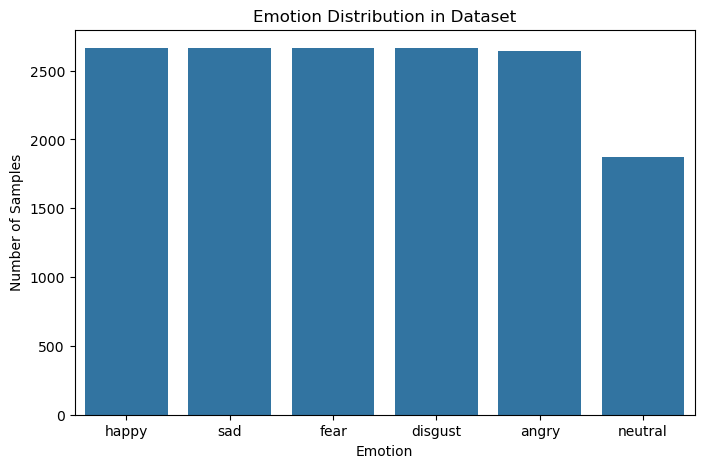

In [12]:
emotion_counts = pd.Series(y).value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values)

plt.title("Emotion Distribution in Dataset")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.show()

In [13]:
X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (15168, 128, 130)


In [15]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

y_cat = to_categorical(y_encoded)

print("Emotion Classes:", encoder.classes_)

Emotion Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42
)

In [17]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / (std + 1e-6)
X_test = (X_test - mean) / (std + 1e-6)

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [18]:
model = tf.keras.Sequential([

tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,130,1)),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.MaxPooling2D((2,2)),

tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.MaxPooling2D((2,2)),

tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.MaxPooling2D((2,2)),

tf.keras.layers.Flatten(),

tf.keras.layers.Dense(256,activation='relu'),
tf.keras.layers.Dropout(0.4),

tf.keras.layers.Dense(len(encoder.classes_),activation='softmax')

])

C:\Users\pasha\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
optimizer="adam",
loss="categorical_crossentropy",
metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 62, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 62, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 29, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 29, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,517,894 (24.86 MB)

 Trainable params: 6,517,446 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
history = model.fit(

X_train,
y_train,

validation_data=(X_test,y_test),

epochs=40,
batch_size=32

)

Epoch 1/40
380/380 ━━━━━━━━━━━━━━━━━━━━ 127s 327ms/step - accuracy: 0.2730 - loss: 2.1380 - val_accuracy: 0.3392 - val_loss: 1.6272
Epoch 2/40
380/380 ━━━━━━━━━━━━━━━━━━━━ 126s 331ms/step - accuracy: 0.3573 - loss: 1.5010 - val_accuracy: 0.4878 - val_loss: 1.2103
Epoch 3/40
380/380 ━━━━━━━━━━━━━━━━━━━━ 124s 326ms/step - accuracy: 0.4480 - loss: 1.3158 - val_accuracy: 0.5686 - val_loss: 1.1117
Epoch 4/40
380/380 ━━━━━━━━━━━━━━━━━━━━ 124s 326ms/step - accuracy: 0.5393 - loss: 1.1297 - val_accuracy: 0.7060 - val_loss: 0.8210
Epoch 5/40
380/380 ━━━━━━━━━━━━━━━━━━━━ 119s 314ms/step - accuracy: 0.6061 - loss: 0.9907 - val_accuracy: 0.7446 - val_loss: 0.7409
Epoch 6/40
380/380 ━━━━━━━━━━━━━━━━━━━━ 121s 319ms/step - accuracy: 0.6569 - loss: 0.8705 - val_accuracy: 0.7528 - val_loss: 0.7509
Epoch 7/40
380/380 ━━━━━━━━━━━━━━━━━━━━ 125s 329ms/step - accuracy: 0.7067 - loss: 0.7612 - val_accuracy: 0.8510 - val_loss: 0.4874
Epoch 8/40
380/380 ━━━━━━━━━━━━━━━━━━━━ 125s 329ms/step - accuracy: 0.7397 -

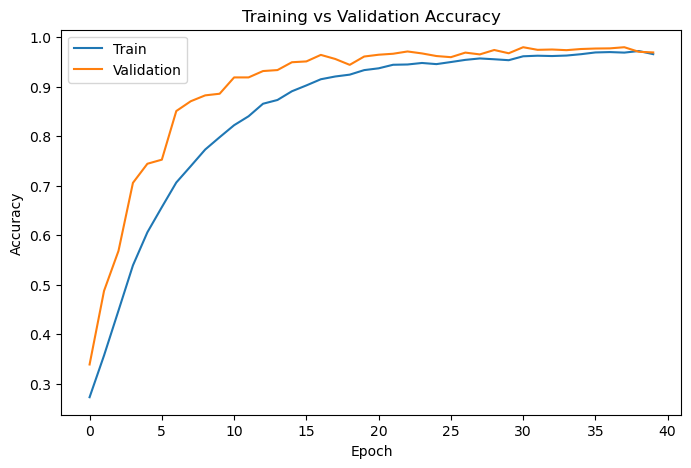

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

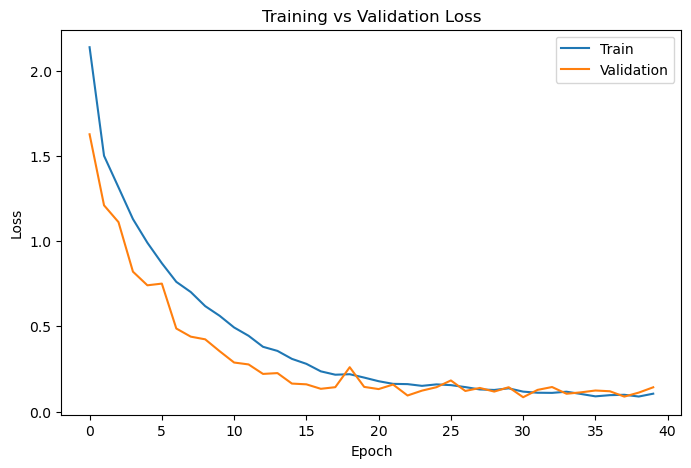

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [23]:
loss,acc = model.evaluate(X_test,y_test)

print("Test Accuracy:",acc)

95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9693 - loss: 0.1424
Test Accuracy: 0.9693474173545837


95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step


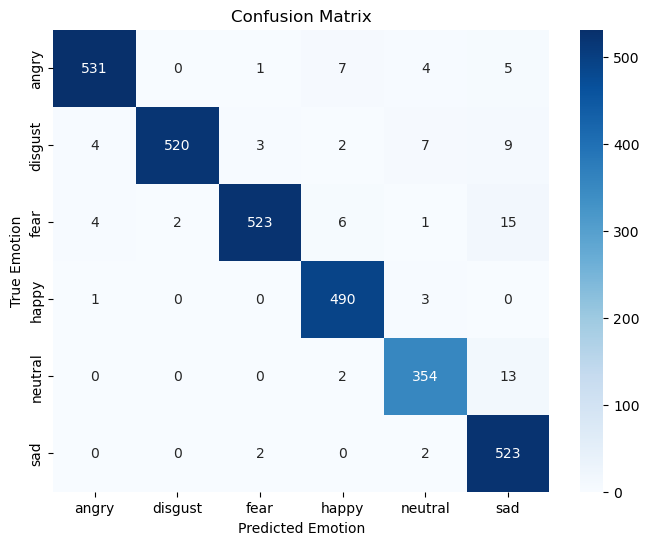

In [24]:
y_pred = model.predict(X_test)

y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap="Blues"
)

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")

plt.title("Confusion Matrix")

plt.show()

In [45]:
model.save("speech_model.keras")

np.save("mean.npy",mean)
np.save("std.npy",std)

with open("label_encoder.pkl","wb") as f:
    pickle.dump(encoder,f)

In [46]:
import numpy as np
import librosa
import tensorflow as tf
import pickle

# load model
model = tf.keras.models.load_model("speech_model.keras")

# load normalization stats
mean = np.load("mean.npy")
std = np.load("std.npy")

# load label encoder
with open("label_encoder.pkl","rb") as f:
    encoder = pickle.load(f)

print("Model loaded successfully")

Model loaded successfully


In [47]:
def extract_features(audio, sr=22050, n_mels=128, max_len=130):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels
    )

    log_mel = librosa.power_to_db(mel)

    if log_mel.shape[1] < max_len:

        pad = max_len - log_mel.shape[1]

        log_mel = np.pad(
            log_mel,
            ((0,0),(0,pad)),
            mode="constant"
        )

    else:
        log_mel = log_mel[:, :max_len]

    return log_mel

In [48]:
def predict_emotion(file):

    audio, sr = librosa.load(file, sr=22050)

    # remove silence
    audio,_ = librosa.effects.trim(audio, top_db=25)

    # normalize audio
    audio = librosa.util.normalize(audio)

    log_mel = extract_features(audio)

    log_mel = (log_mel - mean) / (std + 1e-6)

    log_mel = log_mel[np.newaxis, ..., np.newaxis]

    pred = model.predict(log_mel, verbose=0)

    index = np.argmax(pred)

    confidence = float(np.max(pred))

    emotion = encoder.inverse_transform([index])[0]

    print("Predicted Emotion:", emotion)
    print("Confidence:", round(confidence*100,2), "%")

    return emotion

In [50]:
predict_emotion("C:/Users/pasha/pca/datasets/.wav")

Predicted Emotion: angry
Confidence: 69.46 %


np.str_('angry')

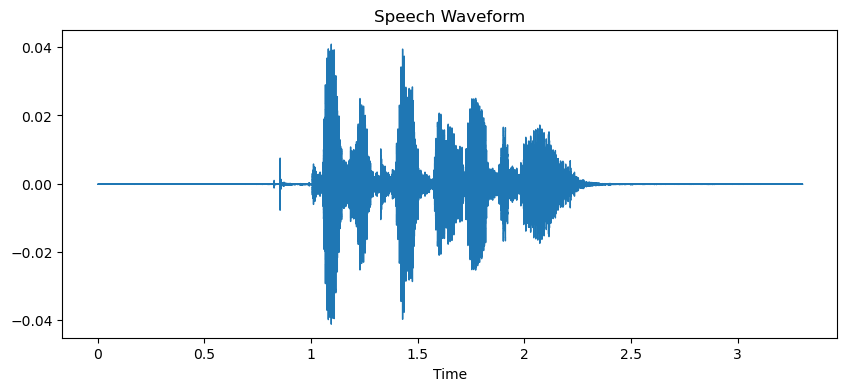

In [39]:
audio, sr = librosa.load(os.path.join(RAVDESS_PATH, os.listdir(RAVDESS_PATH)[0]))

plt.figure(figsize=(10,4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Speech Waveform")

plt.show()

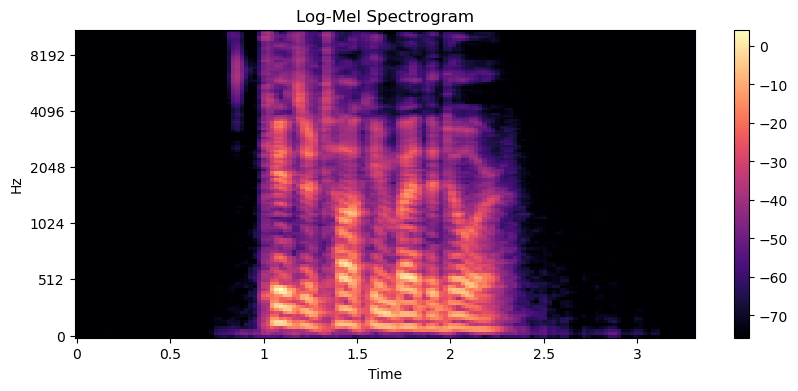

In [40]:
mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)

log_mel = librosa.power_to_db(mel)

plt.figure(figsize=(10,4))

librosa.display.specshow(
log_mel,
sr=sr,
x_axis="time",
y_axis="mel"
)

plt.colorbar()

plt.title("Log-Mel Spectrogram")

plt.show()